In [28]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [29]:
class BMIState(TypedDict):
    height: float
    weight: float
    bmi: float
    classification: str

In [30]:
def calculate_bmi(state: BMIState) -> BMIState:
    height = state['height']
    weight = state['weight']

    bmi = weight / (height ** 2)
    state['bmi'] = bmi

    return state

In [31]:
def classify_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state['classification'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['classification'] = 'Normal'
    elif 25 <= bmi < 30:
        state['classification'] = 'Overweight'
    else:
        state['classification'] = 'Obese'

    return state

In [32]:
# Graph
graph = StateGraph(BMIState)
# Nodes
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("classify_bmi", classify_bmi)

# Edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "classify_bmi")
graph.add_edge("classify_bmi", END)

workflow = graph.compile()

In [36]:
initial_state = {"height": 1.75, "weight": 60}

state = workflow.invoke(initial_state)
print(state)

{'height': 1.75, 'weight': 60, 'bmi': 19.591836734693878, 'classification': 'Normal'}


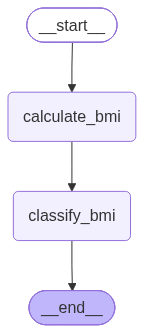

In [37]:
from IPython.display import Image,display
display(Image(workflow.get_graph().draw_mermaid_png()))